# 🔍 Análisis de OUTLIERS (Valores Extremos)

## ¿Qué es un OUTLIER?

Un **outlier** (valor atípico) es un **dato que está MUY ALEJADO del resto**.

### Ejemplo simple:
Si la mayoría de pacientes tienen entre 50-80 años, pero hay uno de **16 años** → ESO es un outlier.

### ¿Por qué importa en Machine Learning?
- Los outliers pueden **distorsionar** los modelos
- Hay que decidir: **¿Los eliminamos o los dejamos?**
- Depende de si son **errores** o **datos válidos**

In [1]:
# Cargar dataset y librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
plt.style.use('default')
sns.set_palette("husl")

# Cargar dataset limpio
df = pd.read_csv('dataset_clean_final.csv')
print(f"Dataset: {len(df):,} pacientes, {len(df.columns)} columnas")

Dataset: 91,713 pacientes, 87 columnas


## 📐 ¿Cómo detectamos outliers?

Usamos el método **IQR (Rango Intercuartílico)**:

```
         Q1          Mediana         Q3
          |              |              |
    ------[==============|==============]------
          ^                              ^
     25% datos                       75% datos
```

**Outliers** = Valores que caen FUERA de:
- Límite inferior: `Q1 - 1.5 × IQR`
- Límite superior: `Q3 + 1.5 × IQR`

Donde `IQR = Q3 - Q1` (rango del 50% central de datos)

### ¿Qué significa el porcentaje?

**Porcentaje de outliers** = Del total de pacientes, cuántos tienen valores extremos (fuera del rango normal).

**Ejemplo**: Si una columna tiene 20% de outliers → significa que 1 de cada 5 pacientes tiene un valor muy alejado del resto.

In [2]:
def detectar_outliers(columna):
    """Detecta outliers en una columna"""
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr

    # Encontrar outliers
    outliers = (df[columna] < limite_inf) | (df[columna] > limite_sup)
    n_outliers = outliers.sum()
    porcentaje = (n_outliers / len(df)) * 100

    return {
        'columna': columna,
        'total_outliers': n_outliers,
        'porcentaje': porcentaje,
        'min': df[columna].min(),
        'max': df[columna].max(),
        'q1': q1,
        'q3': q3,
        'limite_inf': limite_inf,
        'limite_sup': limite_sup,
        'outliers_mask': outliers
    }

print("Funcion creada!")

Funcion creada!


In [3]:
# Analizar todas las columnas numéricas
columnas_num = df.select_dtypes(include=['int64', 'float64']).columns

resultados = []
for col in columnas_num:
    info = detectar_outliers(col)
    if info['total_outliers'] > 0:
        resultados.append(info)

# Ordenar por % de outliers
resultados.sort(key=lambda x: x['porcentaje'], reverse=True)

# TOP 10
print("="*70)
print("TOP 10 COLUMNAS CON MAS OUTLIERS (valores extremos)")
print("="*70)
for i, r in enumerate(resultados[:10], 1):
    print(f"{i}. {r['columna']}")
    print(f"   Outliers: {r['total_outliers']:,} ({r['porcentaje']:.1f}%)")
    print(f"   Rango: [{r['min']:.1f}, {r['max']:.1f}]")
    print()

TOP 10 COLUMNAS CON MAS OUTLIERS (valores extremos)
1. icu_type_encoded
   Outliers: 20,981 (22.9%)
   Rango: [0.0, 7.0]

2. diabetes_mellitus
   Outliers: 20,492 (22.3%)
   Rango: [0.0, 1.0]

3. ethnicity_encoded
   Outliers: 19,634 (21.4%)
   Rango: [0.0, 5.0]

4. gcs_motor_apache
   Outliers: 18,852 (20.6%)
   Rango: [1.0, 6.0]

5. gcs_verbal_apache
   Outliers: 18,681 (20.4%)
   Rango: [1.0, 5.0]

6. apache_post_operative
   Outliers: 18,444 (20.1%)
   Rango: [0.0, 1.0]

7. elective_surgery
   Outliers: 16,851 (18.4%)
   Rango: [0.0, 1.0]

8. pre_icu_los_days
   Outliers: 15,815 (17.2%)
   Rango: [-24.9, 159.1]

9. intubated_apache
   Outliers: 13,761 (15.0%)
   Rango: [0.0, 1.0]

10. apache_4a_icu_death_prob
   Outliers: 13,377 (14.6%)
   Rango: [-1.0, 1.0]



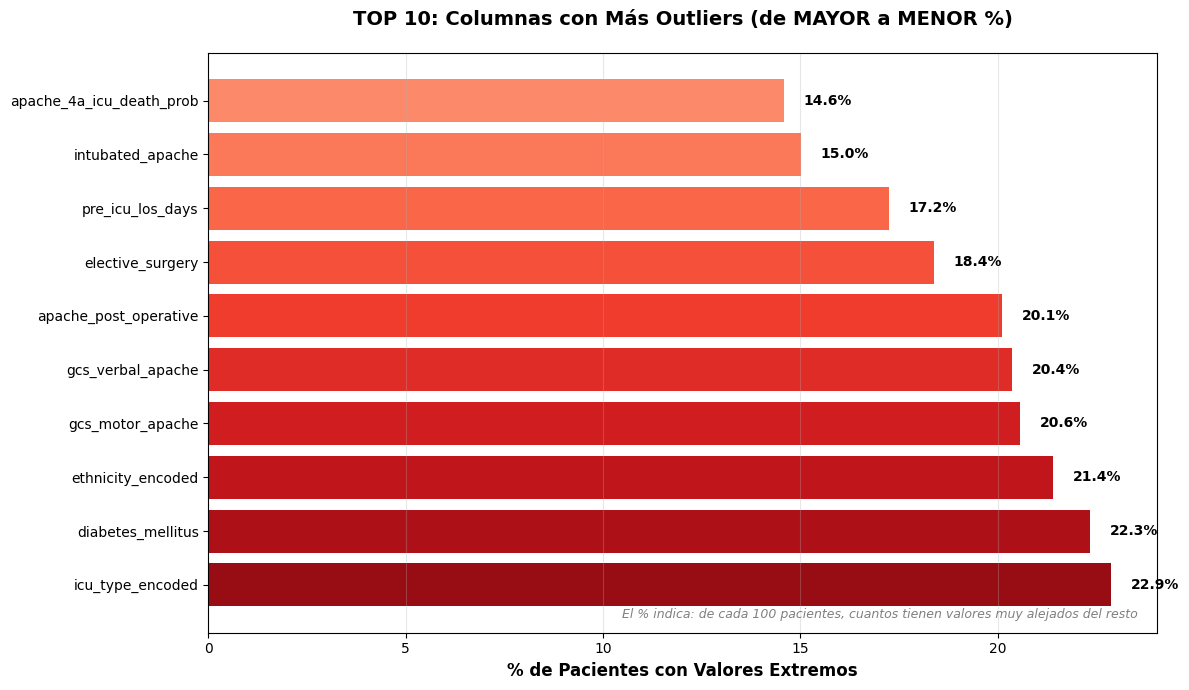


INTERPRETACION:
  - Total columnas con outliers: 73
  - La primera columna (icu_type_encoded) tiene el MAYOR % de outliers
  - La ultima columna (apache_4a_icu_death_prob) tiene el MENOR % de outliers (del top 10)
  - Colores: MAS ROJO = MAS OUTLIERS


In [4]:
# Visualizar TOP 10 (ordenado de MAYOR a MENOR % de outliers)
top10 = resultados[:10]

fig, ax = plt.subplots(figsize=(12, 7))

nombres = [r['columna'] for r in top10]
porcentajes = [r['porcentaje'] for r in top10]

# Colores: MAS ROJO = MAS OUTLIERS (invertir el orden)
# El primero (más outliers) será rojo intenso, el último será rojo claro
colores = plt.cm.Reds(np.linspace(0.9, 0.4, 10))  # Invertido: de 0.9 a 0.4

bars = ax.barh(nombres, porcentajes, color=colores)
ax.set_xlabel('% de Pacientes con Valores Extremos', fontsize=12, fontweight='bold')
ax.set_title('TOP 10: Columnas con Más Outliers (de MAYOR a MENOR %)',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, (nombre, pct) in enumerate(zip(nombres, porcentajes)):
    ax.text(pct + 0.5, i, f'{pct:.1f}%',
            va='center', fontweight='bold', fontsize=10)

# Nota explicativa
ax.text(0.98, 0.02,
        'El % indica: de cada 100 pacientes, cuantos tienen valores muy alejados del resto',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.show()

print(f"\nINTERPRETACION:")
print(f"  - Total columnas con outliers: {len(resultados)}")
print(f"  - La primera columna ({nombres[0]}) tiene el MAYOR % de outliers")
print(f"  - La ultima columna ({nombres[-1]}) tiene el MENOR % de outliers (del top 10)")
print(f"  - Colores: MAS ROJO = MAS OUTLIERS")

## 📊 Visualización Detallada: TOP 5 Columnas

Ahora veamos **cómo se ven** los outliers en las 5 columnas con más valores extremos.

**En ROJO** 🔴 = Outliers (valores muy alejados)
**En AZUL** 🔵 = Valores normales

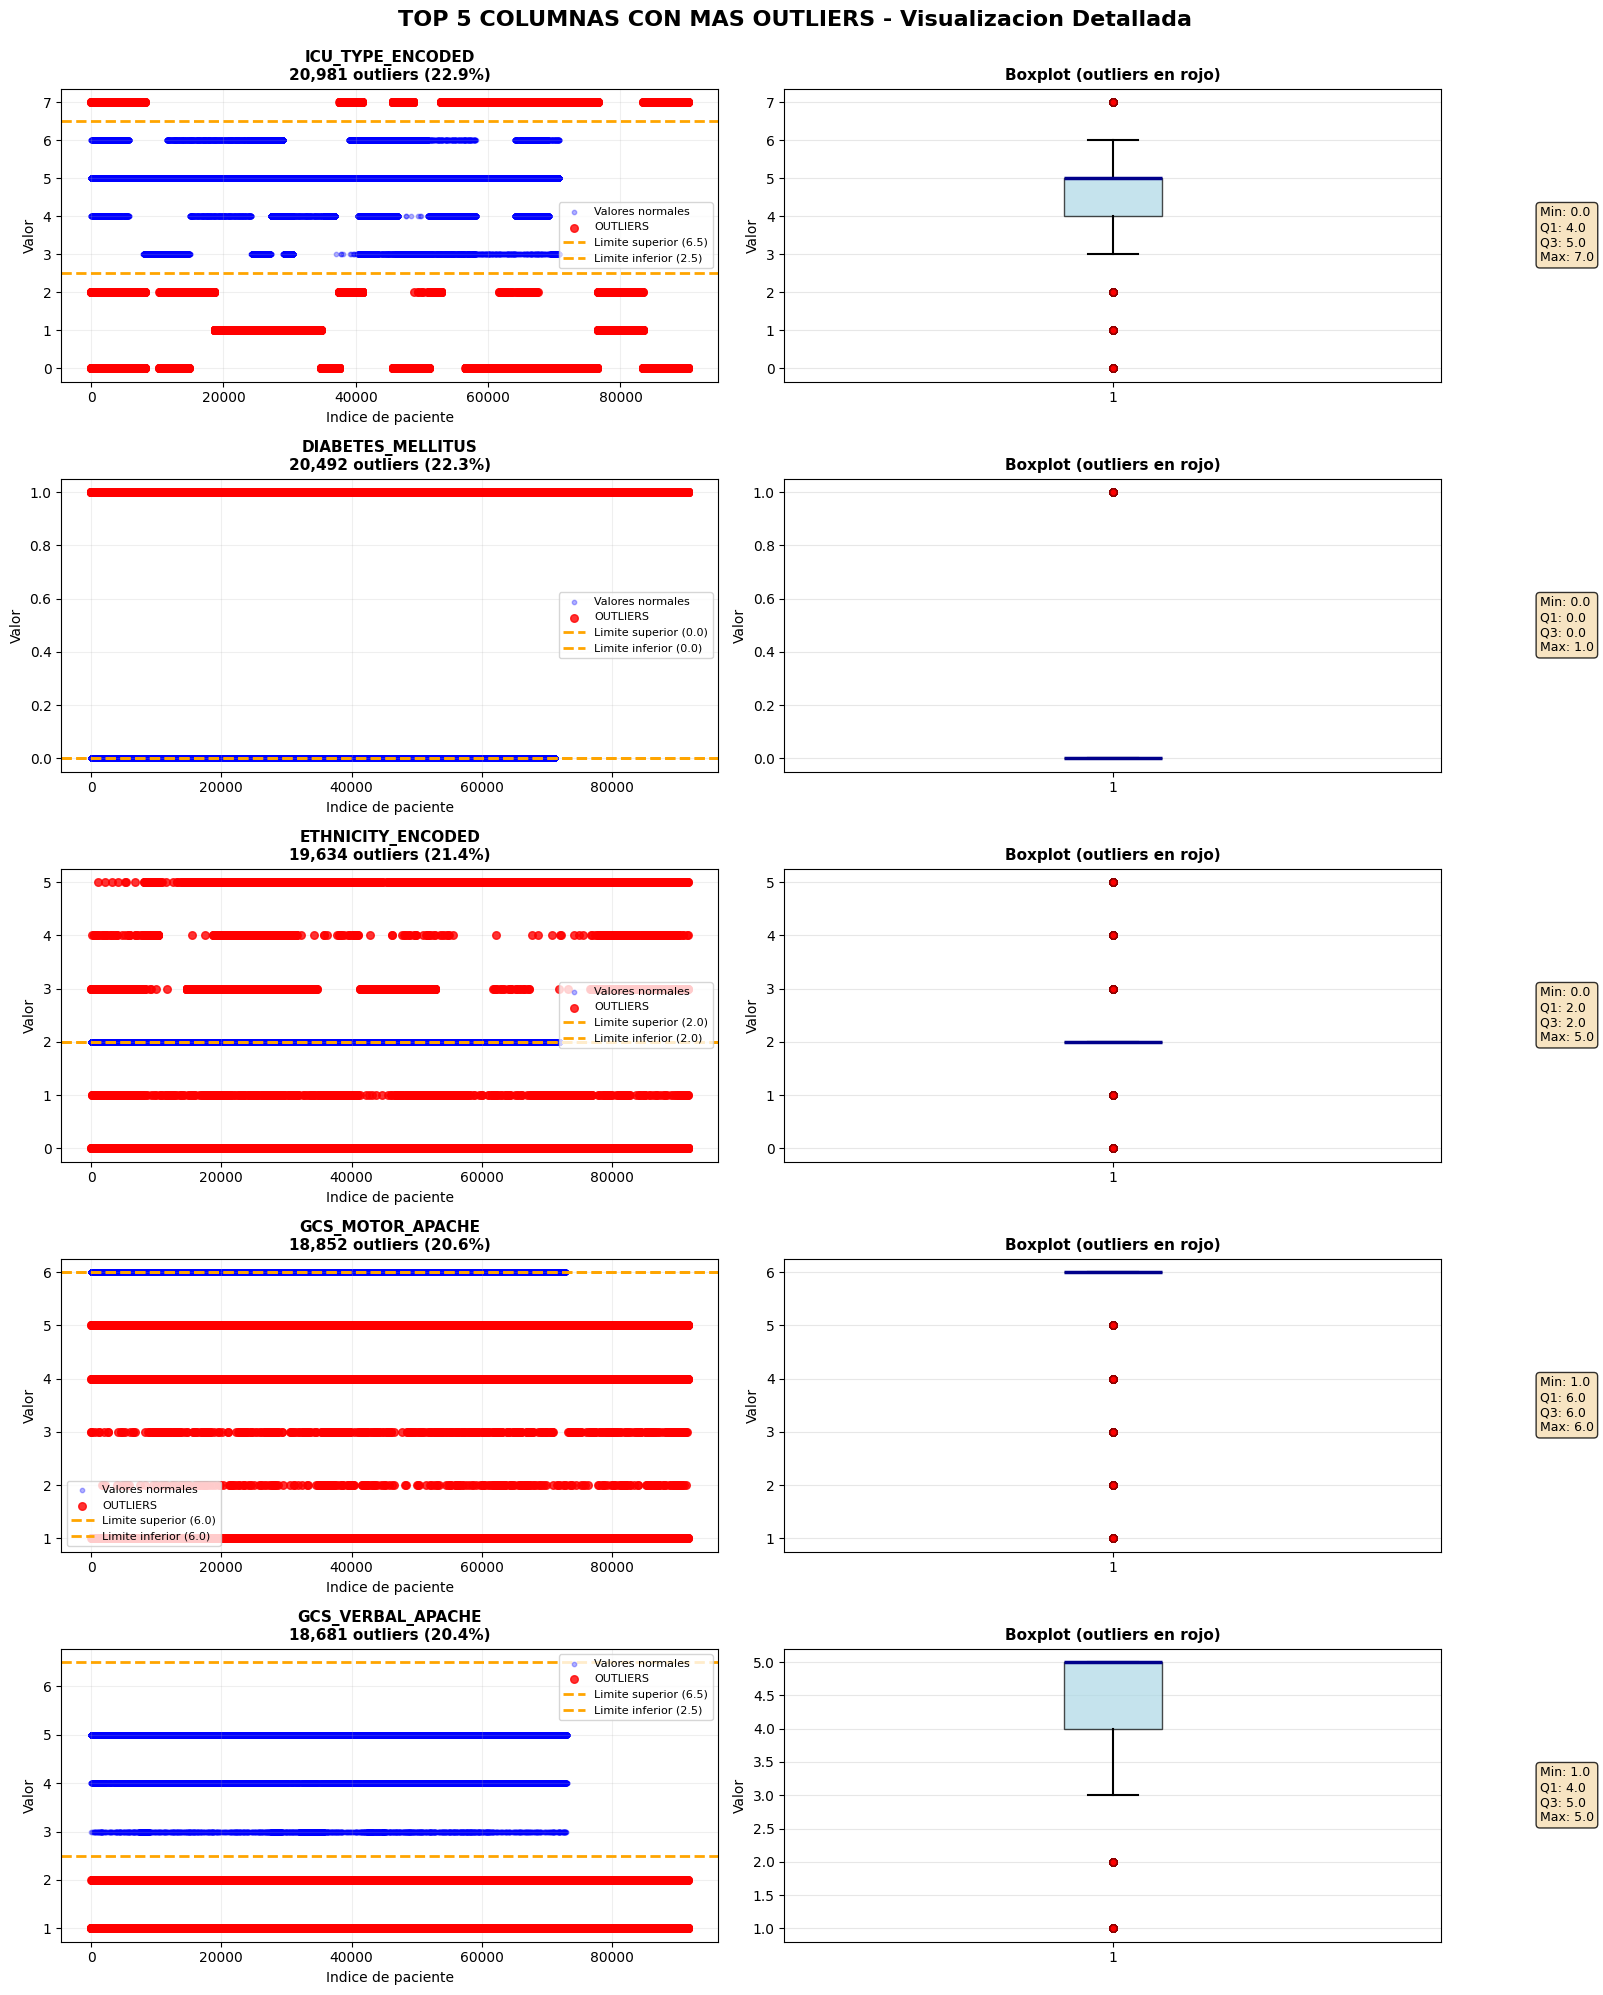

In [5]:
# Visualizar TOP 5 con outliers marcados en ROJO
top5 = resultados[:5]

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
fig.suptitle('TOP 5 COLUMNAS CON MAS OUTLIERS - Visualizacion Detallada',
             fontsize=16, fontweight='bold', y=0.995)

for i, info in enumerate(top5):
    col = info['columna']
    outliers_mask = info['outliers_mask']

    # GRAFICO 1: Distribucion (scatter)
    ax1 = axes[i, 0]

    # Puntos normales en azul
    normales = df[~outliers_mask][col]
    ax1.scatter(range(len(normales)), normales.values,
                alpha=0.3, s=10, color='blue', label='Valores normales')

    # Outliers en ROJO
    outliers_vals = df[outliers_mask][col]
    outliers_indices = df[outliers_mask].index
    ax1.scatter(outliers_indices, outliers_vals.values,
                alpha=0.8, s=30, color='red', label='OUTLIERS', zorder=5)

    # Lineas de límites
    ax1.axhline(info['limite_sup'], color='orange', linestyle='--',
                linewidth=2, label=f'Limite superior ({info["limite_sup"]:.1f})')
    ax1.axhline(info['limite_inf'], color='orange', linestyle='--',
                linewidth=2, label=f'Limite inferior ({info["limite_inf"]:.1f})')

    ax1.set_title(f'{col.upper()}\n{info["total_outliers"]:,} outliers ({info["porcentaje"]:.1f}%)',
                  fontweight='bold', fontsize=11)
    ax1.set_ylabel('Valor', fontsize=10)
    ax1.set_xlabel('Indice de paciente', fontsize=10)
    ax1.legend(fontsize=8, loc='best')
    ax1.grid(alpha=0.2)

    # GRAFICO 2: Boxplot
    ax2 = axes[i, 1]

    bp = ax2.boxplot(df[col], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     medianprops=dict(color='darkblue', linewidth=2.5),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5),
                     flierprops=dict(marker='o', markerfacecolor='red',
                                   markersize=5, alpha=0.6, markeredgecolor='darkred'))

    ax2.set_title('Boxplot (outliers en rojo)', fontweight='bold', fontsize=11)
    ax2.set_ylabel('Valor', fontsize=10)
    ax2.grid(axis='y', alpha=0.3)

    # Texto informativo
    texto = f"Min: {info['min']:.1f}\nQ1: {info['q1']:.1f}\nQ3: {info['q3']:.1f}\nMax: {info['max']:.1f}"
    ax2.text(1.15, 0.5, texto, transform=ax2.transAxes,
             fontsize=9, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

## 🔬 Ejemplos REALES de Outliers en el Dataset

Veamos casos concretos de pacientes con valores extremos:

In [6]:
# Mostrar ejemplos REALES de outliers
print("="*70)
print("EJEMPLOS REALES DE OUTLIERS (Pacientes con valores extremos)")
print("="*70)

# Analizar las 3 primeras columnas del TOP 10
for info in resultados[:3]:
    col = info['columna']
    outliers_mask = info['outliers_mask']

    print(f"\n{col.upper()}:")
    print(f"  Rango normal: [{info['limite_inf']:.1f}, {info['limite_sup']:.1f}]")
    print(f"  Outliers encontrados: {info['total_outliers']:,}")

    # Mostrar 5 ejemplos de outliers
    ejemplos = df[outliers_mask][col].head(5)
    print(f"  Ejemplos de valores extremos:")
    for idx, val in ejemplos.items():
        print(f"    - Paciente {idx}: {val:.1f}")

    print()

EJEMPLOS REALES DE OUTLIERS (Pacientes con valores extremos)

ICU_TYPE_ENCODED:
  Rango normal: [2.5, 6.5]
  Outliers encontrados: 20,981
  Ejemplos de valores extremos:
    - Paciente 0: 2.0
    - Paciente 3: 2.0
    - Paciente 8: 0.0
    - Paciente 9: 0.0
    - Paciente 17: 2.0


DIABETES_MELLITUS:
  Rango normal: [0.0, 0.0]
  Outliers encontrados: 20,492
  Ejemplos de valores extremos:
    - Paciente 0: 1.0
    - Paciente 1: 1.0
    - Paciente 5: 1.0
    - Paciente 6: 1.0
    - Paciente 15: 1.0


ETHNICITY_ENCODED:
  Rango normal: [2.0, 2.0]
  Outliers encontrados: 19,634
  Ejemplos de valores extremos:
    - Paciente 10: 3.0
    - Paciente 17: 3.0
    - Paciente 18: 3.0
    - Paciente 29: 0.0
    - Paciente 39: 0.0



## ✅ DECISIÓN: ¿Qué hicimos con los outliers?

### 🤔 Opciones posibles:

| Opción | Ventajas | Desventajas |
|--------|----------|-------------|
| **1. ELIMINAR outliers** | Datos más "limpios" | Perdemos información valiosa |
| **2. DEJARLOS como están** | Conservamos toda la info | Pueden distorsionar modelos |
| **3. Usar métodos ROBUSTOS** ✅ | Lo mejor de ambos mundos | Requiere técnicas especiales |

---

### 🎯 NUESTRA DECISIÓN: **OPCIÓN 3 - Métodos ROBUSTOS**

#### ¿Qué hicimos?

**NO eliminamos los outliers** porque:
- Son **valores clínicamente VÁLIDOS** (pacientes en estado crítico)
- Contienen **información predictiva** importante
- Eliminarlos = perder casos reales

#### ¿Cómo nos protegimos de su impacto negativo?

**Usamos MEDIANA en lugar de MEDIA para imputar valores faltantes**

```python
# Código usado en la limpieza (clean_dataset_complete.py)
median_val = df[col].median()
df[col] = df[col].fillna(median_val)
```

#### ¿Por qué MEDIANA?

La **MEDIANA** es **ROBUSTA** = NO se afecta por valores extremos

In [7]:
# DEMOSTRACIÓN: MEDIANA vs MEDIA con outliers

# Ejemplo con datos REALES: BMI
col_ejemplo = 'bmi'
print("="*70)
print(f"EJEMPLO REAL: {col_ejemplo.upper()}")
print("="*70)

media = df[col_ejemplo].mean()
mediana = df[col_ejemplo].median()
diferencia = abs(media - mediana)

print(f"\nESTADISTICAS:")
print(f"  Min: {df[col_ejemplo].min():.1f}")
print(f"  Max: {df[col_ejemplo].max():.1f}")
print(f"  MEDIA: {media:.2f}")
print(f"  MEDIANA: {mediana:.2f}")
print(f"  Diferencia: {diferencia:.2f}")

info_bmi = detectar_outliers(col_ejemplo)
print(f"\nOUTLIERS:")
print(f"  Total: {info_bmi['total_outliers']:,} ({info_bmi['porcentaje']:.1f}%)")

print(f"\nINTERPRETACION:")
print(f"  La MEDIA ({media:.2f}) esta afectada por los outliers")
print(f"  La MEDIANA ({mediana:.2f}) representa mejor el 'centro' real")
print(f"  Al usar MEDIANA, protegemos la imputacion de distorsiones")

EJEMPLO REAL: BMI

ESTADISTICAS:
  Min: 14.8
  Max: 67.8
  MEDIA: 29.13
  MEDIANA: 27.65
  Diferencia: 1.47

OUTLIERS:
  Total: 3,665 (4.0%)

INTERPRETACION:
  La MEDIA (29.13) esta afectada por los outliers
  La MEDIANA (27.65) representa mejor el 'centro' real
  Al usar MEDIANA, protegemos la imputacion de distorsiones


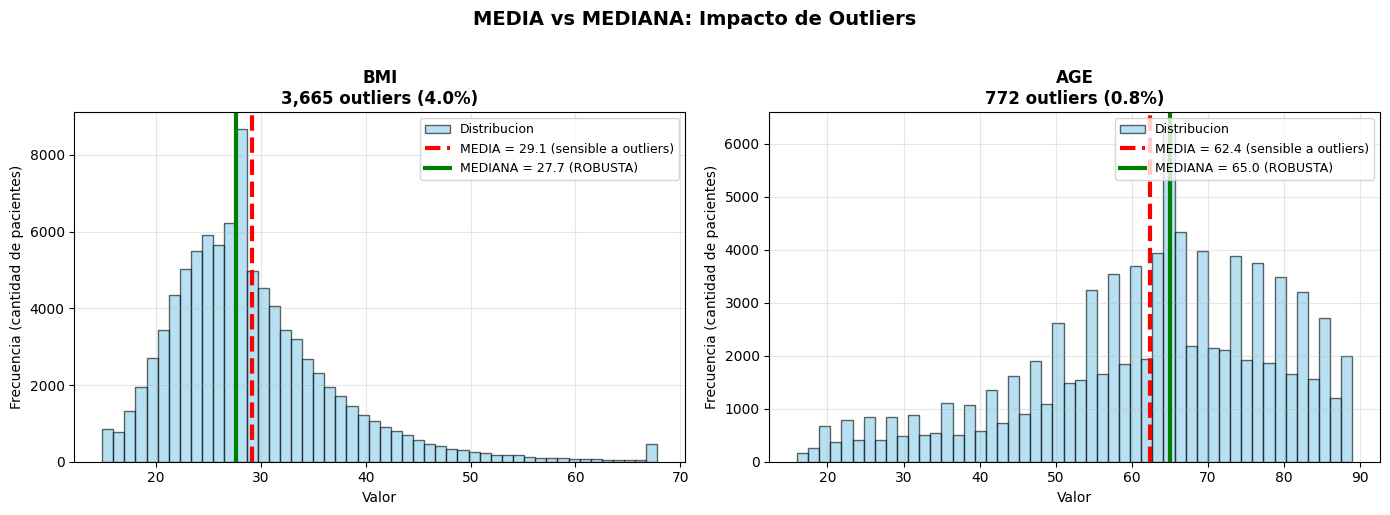


La linea VERDE (mediana) esta mas cerca del 'centro' real de los datos
La linea ROJA (media) se desvia por los valores extremos


In [8]:
# Visualización: Media vs Mediana
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dos ejemplos: BMI y AGE
ejemplos = ['bmi', 'age']

for i, col in enumerate(ejemplos):
    ax = axes[i]

    media = df[col].mean()
    mediana = df[col].median()

    # Histograma
    ax.hist(df[col], bins=50, alpha=0.6, color='skyblue',
            edgecolor='black', label='Distribucion')

    # Líneas verticales
    ax.axvline(media, color='red', linestyle='--', linewidth=3,
               label=f'MEDIA = {media:.1f} (sensible a outliers)')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=3,
               label=f'MEDIANA = {mediana:.1f} (ROBUSTA)')

    info = detectar_outliers(col)
    ax.set_title(f'{col.upper()}\n{info["total_outliers"]:,} outliers ({info["porcentaje"]:.1f}%)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=10)
    ax.set_ylabel('Frecuencia (cantidad de pacientes)', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.3)

plt.suptitle('MEDIA vs MEDIANA: Impacto de Outliers',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nLa linea VERDE (mediana) esta mas cerca del 'centro' real de los datos")
print("La linea ROJA (media) se desvia por los valores extremos")

## 🤖 Impacto en Machine Learning

### ¿Por qué esta decisión es BUENA para ML?

#### 1️⃣ **Datos médicos REALES**
- Un BMI de 67.8 = paciente con obesidad mórbida → **VÁLIDO**
- Una edad de 16 años en UCI → **VÁLIDO** (pacientes jóvenes también ingresan)
- Presión muy alta/baja → **VÁLIDO** (pacientes críticos)

❌ **Eliminarlos = perder casos importantes**

#### 2️⃣ **Imputación ROBUSTA con MEDIANA**
- Al rellenar datos faltantes, usamos un valor **no distorsionado** por extremos
- Los modelos reciben datos más **representativos**

#### 3️⃣ **Modelos se benefician**

| Tipo de Modelo | Beneficio |
|----------------|-----------|
| **Regresión Logística** | Menos influencia de valores extremos en coeficientes |
| **Árboles de Decisión** | Splits más representativos del centro de datos |
| **SVM, KNN** | Escalado no distorsionado por outliers |
| **Redes Neuronales** | Normalización más estable |

#### 4️⃣ **Información predictiva**
- Los outliers pueden ser **MUY informativos** para predecir `hospital_death`
- Ej: Pacientes con signos vitales extremos → mayor riesgo de muerte

In [9]:
# RESUMEN EJECUTIVO
print("="*70)
print("RESUMEN: MANEJO DE OUTLIERS EN EL DATASET")
print("="*70)

total_cols_con_outliers = len(resultados)
total_cols_num = len(columnas_num)

print(f"\nDATOS:")
print(f"  - Pacientes: {len(df):,}")
print(f"  - Columnas numericas: {total_cols_num}")
print(f"  - Columnas con outliers: {total_cols_con_outliers}")

print(f"\nTOP 3 COLUMNAS CON MAS OUTLIERS:")
for i, r in enumerate(resultados[:3], 1):
    print(f"  {i}. {r['columna']}: {r['porcentaje']:.1f}% ({r['total_outliers']:,} valores)")

print(f"\nDECISION TOMADA:")
print(f"  - NO eliminamos outliers (son datos medicos validos)")
print(f"  - Usamos MEDIANA para imputacion (robusta a extremos)")
print(f"  - Conservamos informacion predictiva importante")

print(f"\nRESULTADO:")
print(f"  - Dataset completo y limpio")
print(f"  - {len(df):,} pacientes listos para Machine Learning")
print(f"  - Outliers presentes pero NO distorsionan modelos")

print("\n" + "="*70)

RESUMEN: MANEJO DE OUTLIERS EN EL DATASET

DATOS:
  - Pacientes: 91,713
  - Columnas numericas: 80
  - Columnas con outliers: 73

TOP 3 COLUMNAS CON MAS OUTLIERS:
  1. icu_type_encoded: 22.9% (20,981 valores)
  2. diabetes_mellitus: 22.3% (20,492 valores)
  3. ethnicity_encoded: 21.4% (19,634 valores)

DECISION TOMADA:
  - NO eliminamos outliers (son datos medicos validos)
  - Usamos MEDIANA para imputacion (robusta a extremos)
  - Conservamos informacion predictiva importante

RESULTADO:
  - Dataset completo y limpio
  - 91,713 pacientes listos para Machine Learning
  - Outliers presentes pero NO distorsionan modelos



---

## 📌 CONCLUSIÓN

### ✅ **SÍ tenemos outliers** en el dataset

- Múltiples columnas con valores extremos
- Rangos amplios en variables clínicas (edad, BMI, presión, etc.)

### ✅ **DECISIÓN CORRECTA**: Usar MEDIANA

- Protege los modelos de distorsión
- Conserva información valiosa
- Apropiado para datos médicos reales

### ✅ **Dataset listo para ML**

- 91,713 pacientes
- Sin valores faltantes
- Outliers manejados correctamente

---

**Archivos relacionados:**
- `clean_dataset_complete.py` - Script de limpieza
- `presentacion_limpieza_dataset.ipynb` - Notebook completo de limpieza
- `dataset_clean_final.csv` - Dataset limpio final

---

**Método de detección:** IQR (Interquartile Range)
**Estrategia:** Imputación robusta con mediana
**Resultado:** Dataset óptimo para Machine Learning
